In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import keras
from keras import layers

# Charger le CSV Airline Passengers
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
print(f"\nAperçu :")
print(df.head(10))
print(f"\nMin : {df['Passengers'].min()}, Max : {df['Passengers'].max()}")

Shape : (144, 2)
Colonnes : ['Month', 'Passengers']

Aperçu :
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
5  1949-06         135
6  1949-07         148
7  1949-08         148
8  1949-09         136
9  1949-10         119

Min : 104, Max : 622


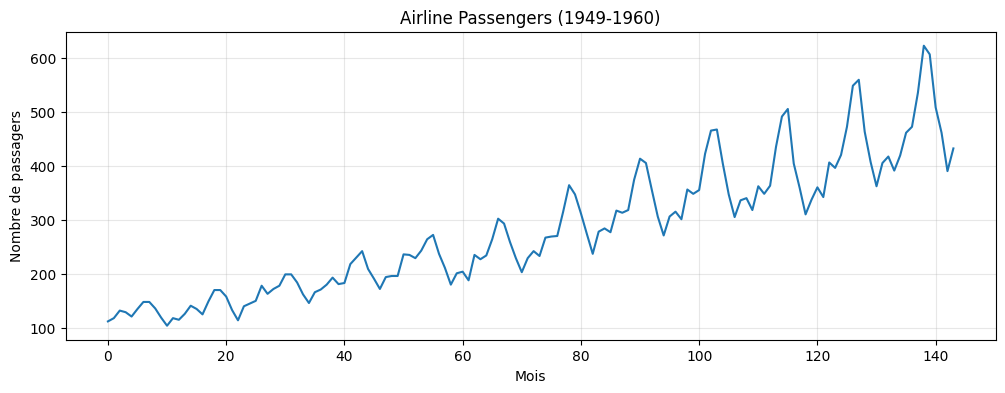

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(df['Passengers'].values)
plt.title("Airline Passengers (1949-1960)")
plt.xlabel("Mois")
plt.ylabel("Nombre de passagers")
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Extraire les valeurs et convertir en float32
data = df['Passengers'].values.astype('float32').reshape(-1, 1)

# Normaliser entre 0 et 1 (le LSTM est sensible aux grandes valeurs)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Split temporel 67/33
split = int(len(data_scaled) * 0.67)
train = data_scaled[:split]
test = data_scaled[split:]

print(f"Data scaled — min : {data_scaled.min():.2f}, max : {data_scaled.max():.2f}")
print(f"Train : {train.shape[0]} points")
print(f"Test  : {test.shape[0]} points")
print(f"Split à l'index {split} (mois {df['Month'].iloc[split]})")

Data scaled — min : 0.00, max : 1.00
Train : 96 points
Test  : 48 points
Split à l'index 96 (mois 1957-01)


In [5]:
def create_dataset(dataset, window_size=12):
    """
    Transforme une série 1D en paires (X, y) via sliding window.
    Retourne X : (N - window_size, window_size, 1), y : (N - window_size,)
    """
    X, y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i:i + window_size, 0])
        y.append(dataset[i + window_size, 0])
    X = np.array(X).reshape(-1, window_size, 1)
    y = np.array(y)
    return X, y

WINDOW_SIZE = 12

X_train, y_train = create_dataset(train, WINDOW_SIZE)
X_test, y_test = create_dataset(test, WINDOW_SIZE)

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (84, 12, 1)
y_train : (84,)
X_test  : (36, 12, 1)
y_test  : (36,)


In [6]:
# Happy path : vérification des shapes et normalisation
assert X_train.shape == (84, 12, 1), f"Shape X_train incorrecte : {X_train.shape}"
assert y_train.shape == (84,), f"Shape y_train incorrecte : {y_train.shape}"
assert data_scaled.min() >= 0 and data_scaled.max() <= 1, "Normalisation hors [0,1]"
print("✅ Happy path OK : shapes correctes, normalisation [0,1]")

# Edge case : window_size=1
X_edge, y_edge = create_dataset(train, window_size=1)
print(f"\n🔍 Edge case window=1 : X={X_edge.shape}, y={y_edge.shape}")
print(f"   Avec 1 seul step de contexte, le modèle ne peut que copier la valeur précédente")

# Adversarial : NaN dans le dataset
data_nan = train.copy()
data_nan[5, 0] = np.nan
X_nan, y_nan = create_dataset(data_nan, WINDOW_SIZE)
has_nan = np.isnan(X_nan).any() or np.isnan(y_nan).any()
print(f"\n⚠️  Adversarial NaN : présence de NaN dans le dataset = {has_nan}")
print(f"   Protection possible : ajouter un assert not np.isnan(dataset).any() en début de create_dataset")

✅ Happy path OK : shapes correctes, normalisation [0,1]

🔍 Edge case window=1 : X=(95, 1, 1), y=(95,)
   Avec 1 seul step de contexte, le modèle ne peut que copier la valeur précédente

⚠️  Adversarial NaN : présence de NaN dans le dataset = True
   Protection possible : ajouter un assert not np.isnan(dataset).any() en début de create_dataset
